In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import plotly.graph_objects as graph_objects
import os

os.makedirs("../reports", exist_ok=True)

plt.style.use("ggplot")

In [43]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")

category = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

In [44]:
nav["date"] = pd.to_datetime(nav["date"])
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [45]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    width=1200
)

fig.write_image("../reports/nav_trend.png")
fig.show()

NAV trend analysis

->Daily NAV trends from 2022-2025 show an overall upward movement across most mutual fund schemes.
-> The highlighted green region represents the 2023 bull run.
->The highlighted red region represents the 2024 market correction.
-> Despite short-term fluctuations, most schemes maintained long-term growth.

In [46]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


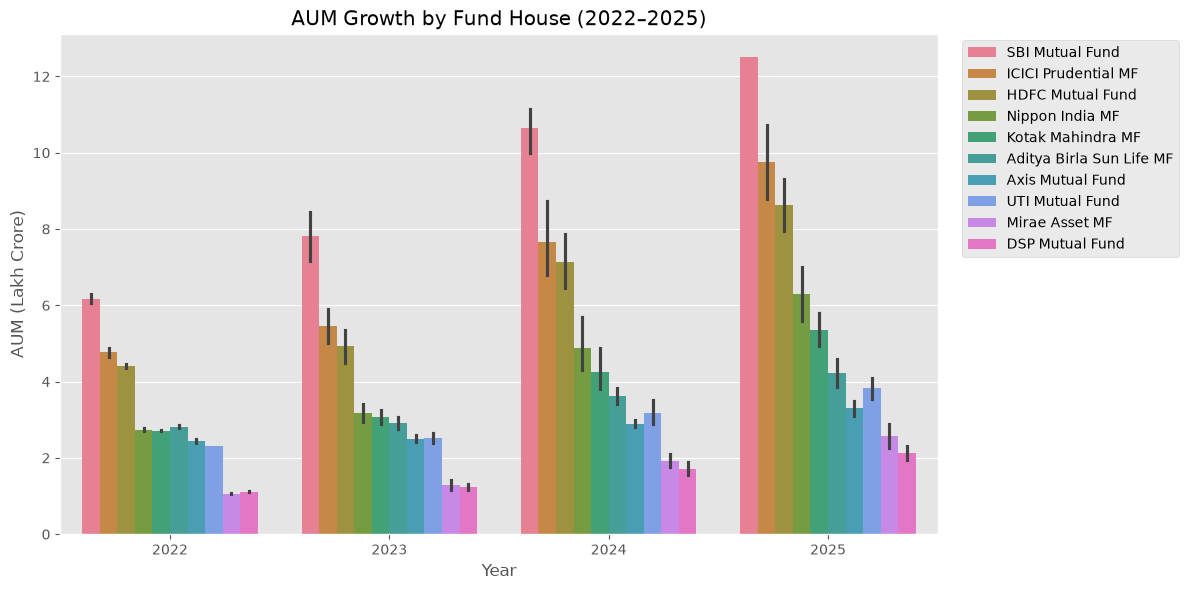

In [47]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("../reports/aum_growth.png", dpi=300, bbox_inches="tight")
plt.show()

-> SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM).

-> Most fund houses showed steady AUM growth from 2022 to 2025.

-> Large fund houses dominated industry assets throughout the analysis period.

In [48]:
# Convert month to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Create a string column for Plotly (fixes Timestamp serialization)
sip["month_str"] = sip["month"].dt.strftime("%b %Y")

# Create line chart
fig = px.line(
    sip,
    x="month_str",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month_str": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    },
    markers=True
)

# Highlight all-time high (Dec 2025)
fig.add_scatter(
    x=[sip.iloc[-1]["month_str"]],
    y=[sip.iloc[-1]["sip_inflow_crore"]],
    mode="markers+text",
    marker=dict(size=10, color="red"),
    text=["₹31,002 Cr\nAll-Time High"],
    textposition="top left",
    showlegend=False
)

# Layout
fig.update_layout(
    template="plotly_white",
    height=600,
    width=1100,
    yaxis=dict(range=[10000, 33000])
)

# Save image
fig.write_image("../reports/sip_trend.png", scale=3)

# Show chart
fig.show()

Monthly SIP Inflow Trend

Monthly SIP inflows increased steadily from **₹11,517 Cr (Jan 2022)** to **₹31,002 Cr (Dec 2025)**.

-> The highest monthly SIP inflow of **₹31,002 Crore** was recorded in **December 2025**.

-> The consistent increase reflects growing retail investor participation and confidence in mutual fund investments.

In [49]:
category["month"] = pd.to_datetime(category["month"])

category["month"] = category["month"].dt.strftime("%b-%Y")

In [50]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


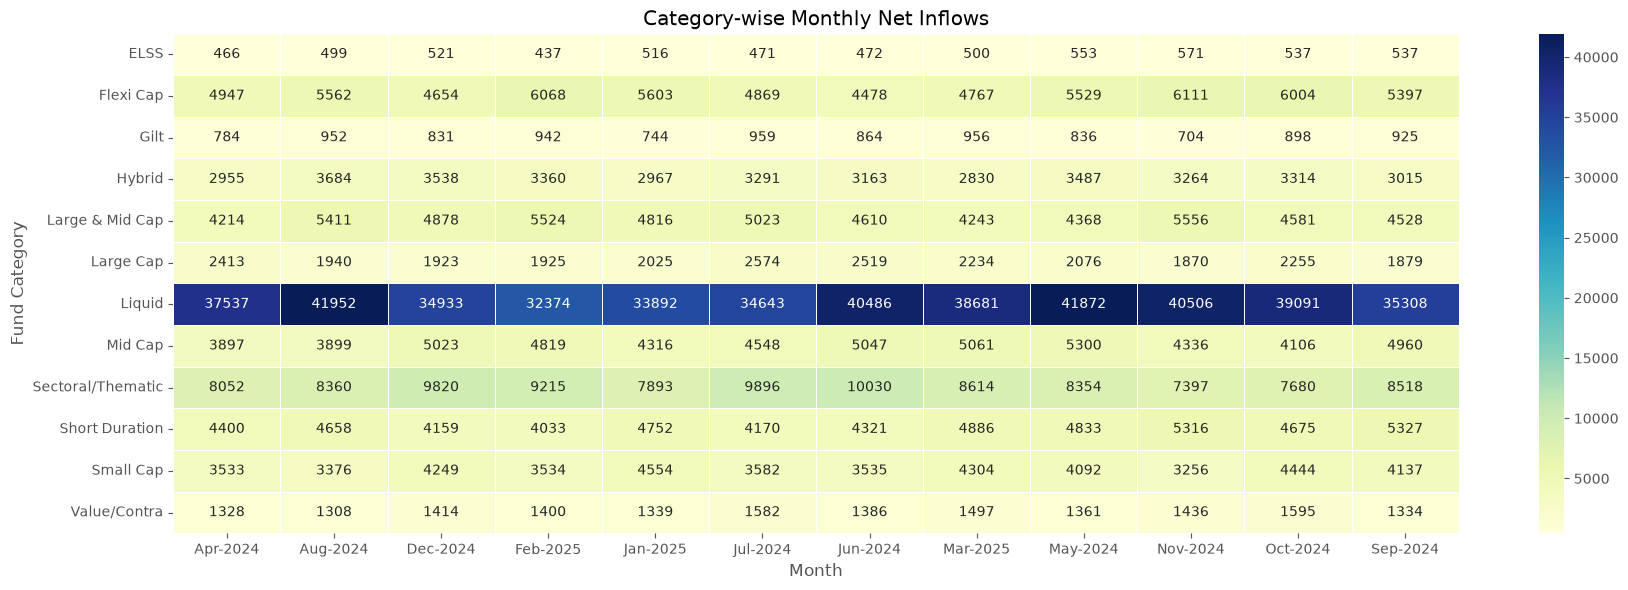

In [51]:
plt.figure(figsize=(18,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.savefig("../reports/category_heatmap.png", dpi=300, bbox_inches="tight")

Category-wise Net Inflow Heatmap

-> Liquid Funds recorded the highest monthly net inflows across the analysis period.

-> Flexi Cap, Mid Cap, and Sectoral/Thematic funds also attracted strong investor interest.

-> Investor preferences varied across categories, indicating changing market sentiment.

In [52]:
age_counts = transactions["age_group"].value_counts()

age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

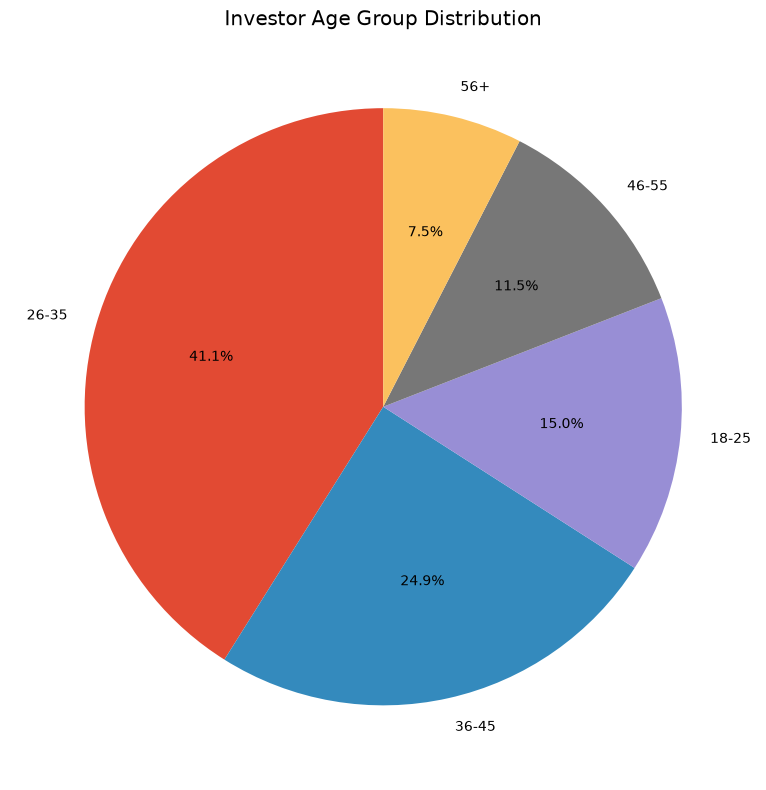

In [53]:
plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.tight_layout()
plt.savefig("../reports/investor_age.png", dpi=300, bbox_inches="tight")
plt.show()


Investor Age Group Distribution
-> Investors aged **26–35 years** form the largest share of the investor base (~41%).

-> The **36–45** age group is the second-largest contributor.

-> Investors aged **56+** represent the smallest proportion, indicating relatively lower participation.

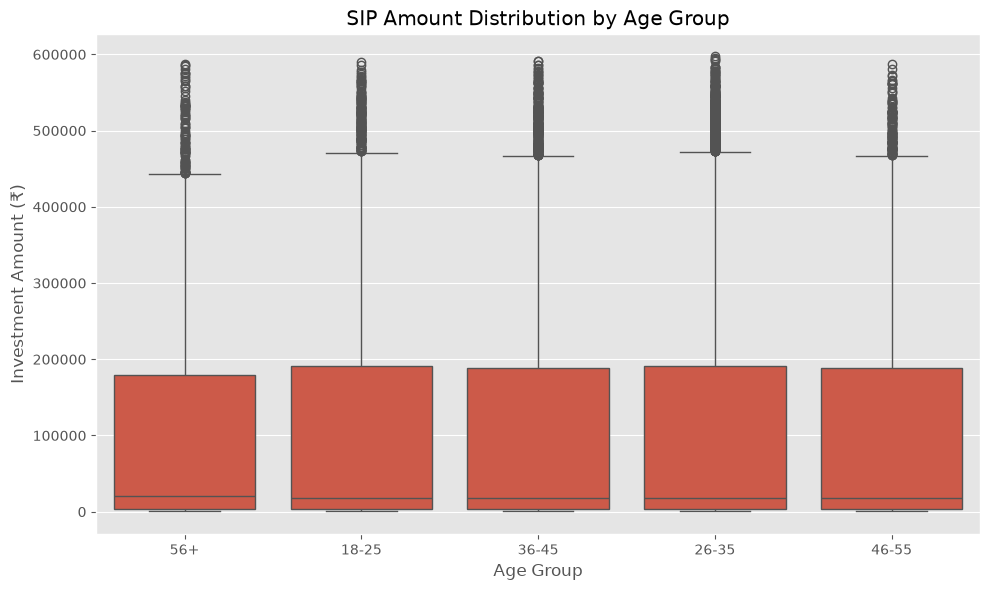

In [54]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()
plt.savefig("../reports/sip_age_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

 SIP Amount Distribution by Age Group

-> All age groups show a wide variation in SIP investment amounts.

-> The median investment amount is relatively similar across age groups.

-> Several high-value investment outliers are present in every age group, indicating that a small number of investors make significantly larger investments.

In [55]:
gender_counts = transactions["gender"].value_counts()

gender_counts

gender
Male      21809
Female    10969
Name: count, dtype: int64

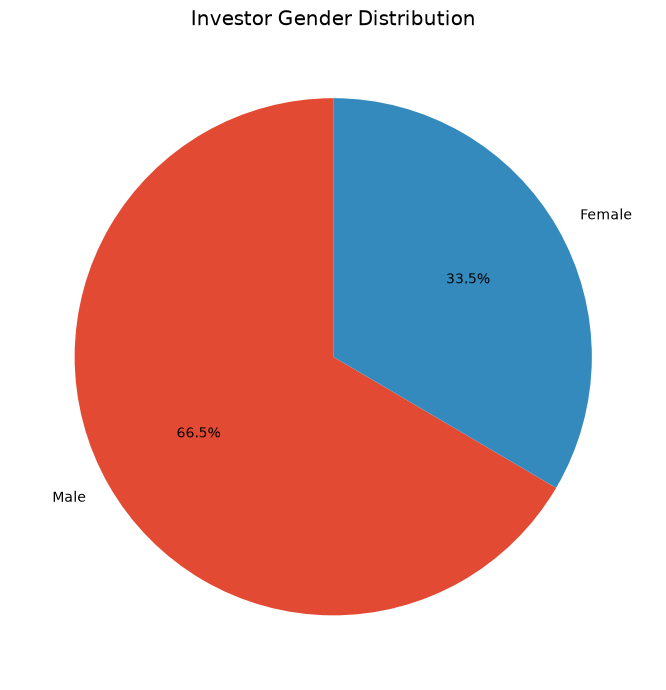

In [56]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.tight_layout()
plt.savefig("../reports/gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Investor Gender Distribution

-> The chart shows the gender composition of mutual fund investors.

-> It highlights the relative participation of male and female investors.

-> The distribution helps understand investor diversity across the dataset.


In [57]:
state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Karnataka         273753570
Maharashtra       269513480
Name: amount_inr, dtype: int64

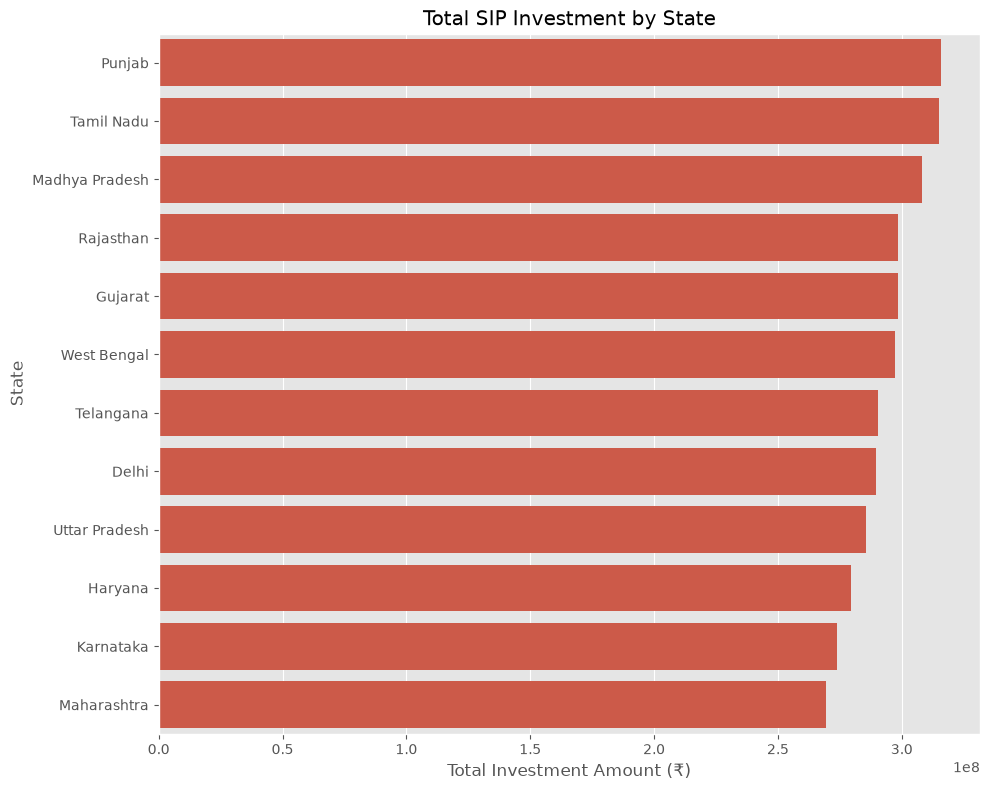

In [58]:
plt.figure(figsize=(10,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Investment by State")
plt.xlabel("Total Investment Amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("../reports/state_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


Geographic Distribution by State

- The chart compares the total SIP investment amount across different states.
- States with higher investment amounts indicate stronger investor participation.
- Investment activity varies significantly across regions.

In [59]:
city_tier_counts = transactions["city_tier"].value_counts()

city_tier_counts

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

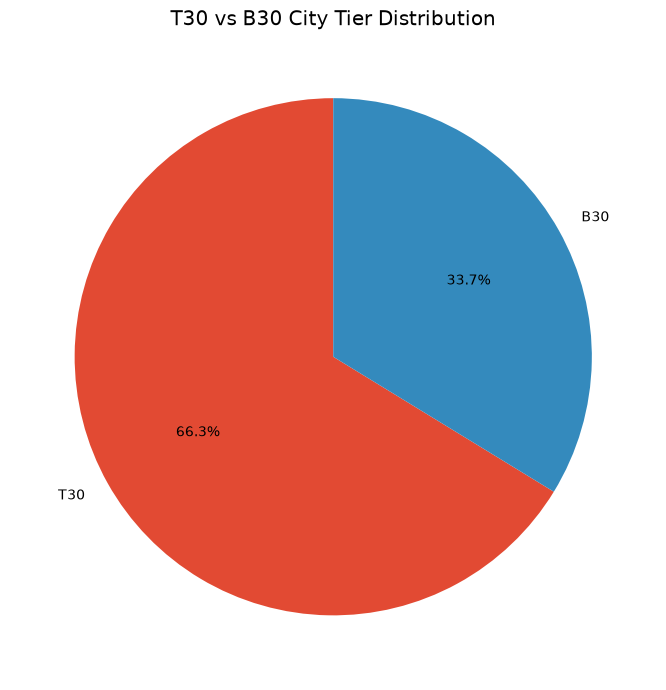

In [60]:
plt.figure(figsize=(7,7))

plt.pie(
    city_tier_counts,
    labels=city_tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.tight_layout()
plt.savefig("../reports/T30vsB30.png", dpi=300, bbox_inches="tight") 
plt.show()

 T30 vs B30 City Tier Distribution

- The chart compares investor participation between T30 and B30 cities.
- T30 cities account for a larger share of investments, reflecting stronger mutual fund penetration.
- B30 cities also contribute significantly, indicating expanding investor participation beyond major metropolitan areas.

In [61]:
folio["month"] = pd.to_datetime(folio["month"])

folio = folio.sort_values("month")

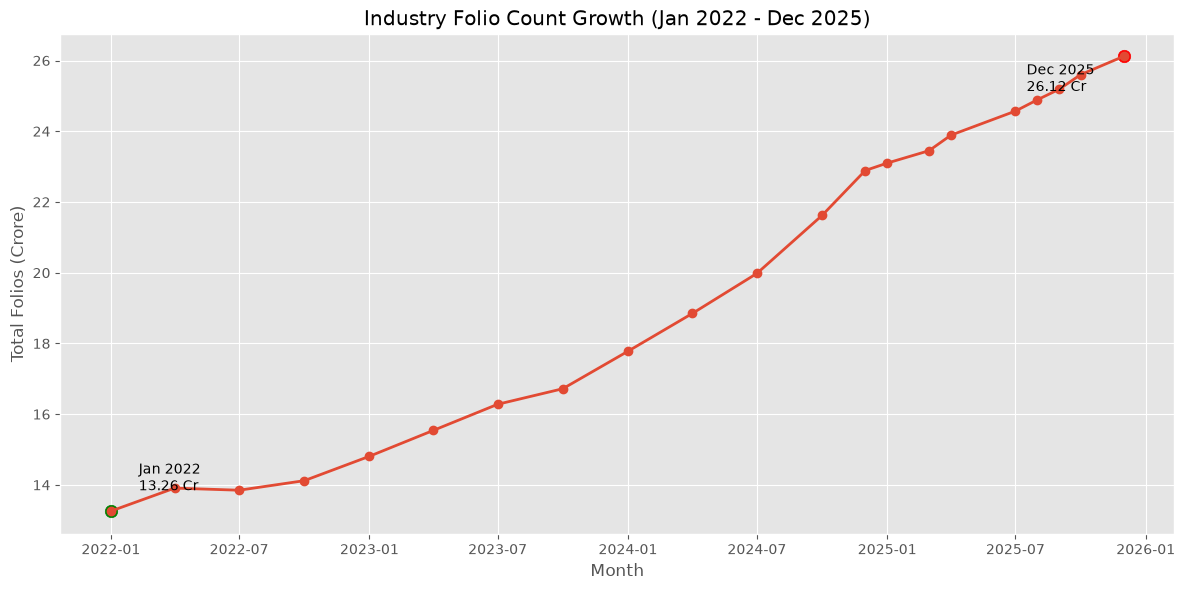

In [62]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Industry Folio Count Growth (Jan 2022 - Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.scatter(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"],
    color="green",
    s=80
)

plt.scatter(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"],
    color="red",
    s=80
)

plt.annotate(
    "Jan 2022\n13.26 Cr",
    (
        folio.iloc[0]["month"],
        folio.iloc[0]["total_folios_crore"]
    ),
    xytext=(20,15),
    textcoords="offset points"
)

plt.annotate(
    "Dec 2025\n26.12 Cr",
    (
        folio.iloc[-1]["month"],
        folio.iloc[-1]["total_folios_crore"]
    ),
    xytext=(-70,-25),
    textcoords="offset points"
)
plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/folio_growth.png", dpi=300, bbox_inches="tight")
plt.show()

Industry Folio Count Growth

- Total mutual fund folios increased from **13.26 Cr (Jan 2022)** to **26.12 Cr (Dec 2025)**.
- The steady rise indicates growing retail investor participation in mutual funds.
- The industry witnessed continuous folio growth throughout the analysis period.

In [63]:
selected_codes = nav["amfi_code"].unique()[:10]

nav_10 = nav[nav["amfi_code"].isin(selected_codes)]

nav_10.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [64]:
pivot_nav = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot_nav.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [65]:
daily_returns = pivot_nav.pct_change()

correlation_matrix = daily_returns.corr()

correlation_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


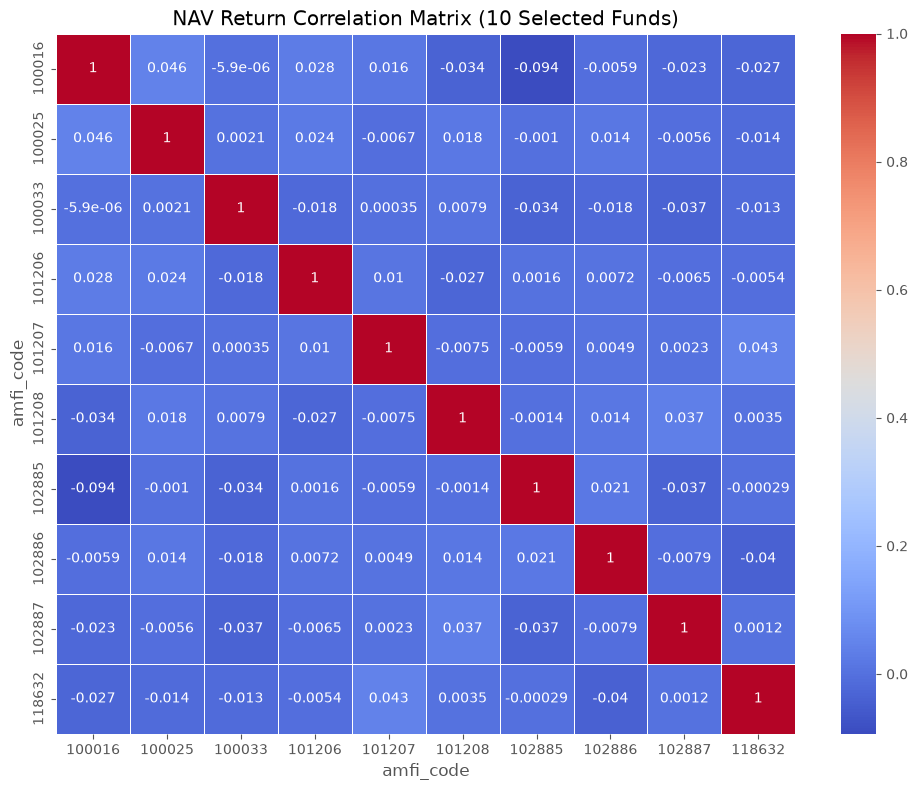

In [66]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix (10 Selected Funds)")
plt.tight_layout()
plt.savefig("../reports/nav_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

 NAV Return Correlation Matrix

- The heatmap shows the correlation between daily NAV returns of 10 selected mutual fund schemes.
- Higher positive correlation indicates funds moving in similar market conditions.
- Lower correlation suggests diversification opportunities across schemes.

In [67]:
sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

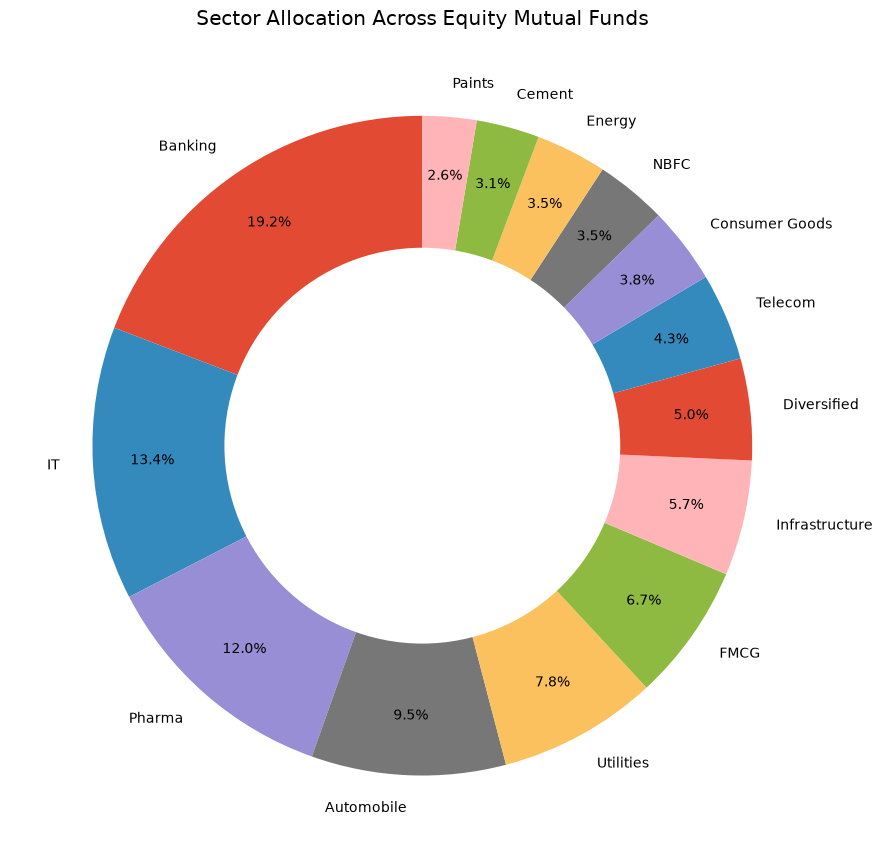

In [68]:
plt.figure(figsize=(9,9))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.82
)

centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Mutual Funds")

plt.tight_layout()
plt.savefig("../reports/sector_allocation.png", dpi=300, bbox_inches="tight")
plt.show()

Sector Allocation Donut Chart

- The portfolio is diversified across multiple industry sectors.
- The largest sectors contribute the highest allocation in equity mutual fund portfolios.
- Sector allocation helps understand portfolio diversification and investment concentration.

====================FINAL EDA FINDINGS=======================

1. Daily NAV values showed an overall upward trend from 2022 to 2025 despite periodic market corrections.

2. SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among all fund houses.

3. Monthly SIP inflows increased from ₹11,517 Cr (Jan 2022) to an all-time high of ₹31,002 Cr (Dec 2025).

4. Liquid Funds attracted the highest category-wise monthly net inflows throughout the analysis period.

5. Investors aged 26–35 represented the largest investor segment.

6. Male investors contributed a larger share of the investor base than female investors.

7. T30 cities accounted for a significantly higher investment share compared to B30 cities.

8. Industry folio count nearly doubled from 13.26 Cr to 26.12 Cr, indicating strong retail participation.

9. Daily NAV returns among selected mutual funds showed generally low correlations, suggesting diversification benefits.

10. Portfolio holdings were diversified across multiple sectors, with Banking, IT, and Pharma receiving the largest allocations.